# Análisis de Sincronización de Fase: Hilbert + Parámetro de Orden de Kuramoto

Objetivo: Identificar el desfase temporal óptimo entre FormacionMWEntT11TempPV y FormacionMWSalT12TempPV
usando transformada de Hilbert para extraer fases y el parámetro de orden de Kuramoto para medir sincronización.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.signal import hilbert
from scipy.ndimage import uniform_filter1d

plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 12

# Load data
df = pd.read_parquet('../data/datos_ind.pqt')
df['fecha'] = pd.to_datetime(df['fecha'])
df = df.set_index('fecha')
print(f'Shape: {df.shape}')
print(f'Date range: {df.index.min()} to {df.index.max()}')
print(f'Columns: {df.columns.tolist()}')

Shape: (24383269, 10)
Date range: 2021-01-03 01:35:46.772000 to 2021-12-23 00:00:00.287000
Columns: ['FormacionNIRHumedadPV', 'BasculaMantaPesoPV', 'SierrasAnchoPV', 'FormacionMantaCentroAltura', 'FormacionAlturaMantaPV', 'FormacionVelocidadSP', 'FormacionVelocidad', 'FormacionMWEntT11TempPV', 'MWPotenciaPV', 'FormacionMWSalT12TempPV']


In [4]:
# Select a 1-hour window
start_time = '2021-11-03 12:00:00'
end_time = '2021-11-03 12:20:00'

df_hour = df.loc[start_time:end_time].copy()
print(f'Window: {df_hour.index[0]} to {df_hour.index[-1]}')
print(f'Length: {len(df_hour)} samples ({len(df_hour)/3600:.2f} hours)')

# Extract the two series
s1 = df_hour['FormacionMWSalT12TempPV'].values
s2 = df_hour['FormacionMWEntT11TempPV'].values

# Check for NaN
print(f'NaN in s1: {np.isnan(s1).sum()}')
print(f'NaN in s2: {np.isnan(s2).sum()}')

# Interpolate any NaN
s1 = pd.Series(s1).interpolate().values
s2 = pd.Series(s2).interpolate().values

Window: 2021-11-03 12:00:00.311000 to 2021-11-03 12:20:00.518000
Length: 1200 samples (0.33 hours)
NaN in s1: 0
NaN in s2: 0


s1_norm: mean=-0.000000, std=0.3961, range=[-0.8906, 1.0000]
s2_norm: mean=0.000000, std=0.3277, range=[-0.7800, 1.0000]


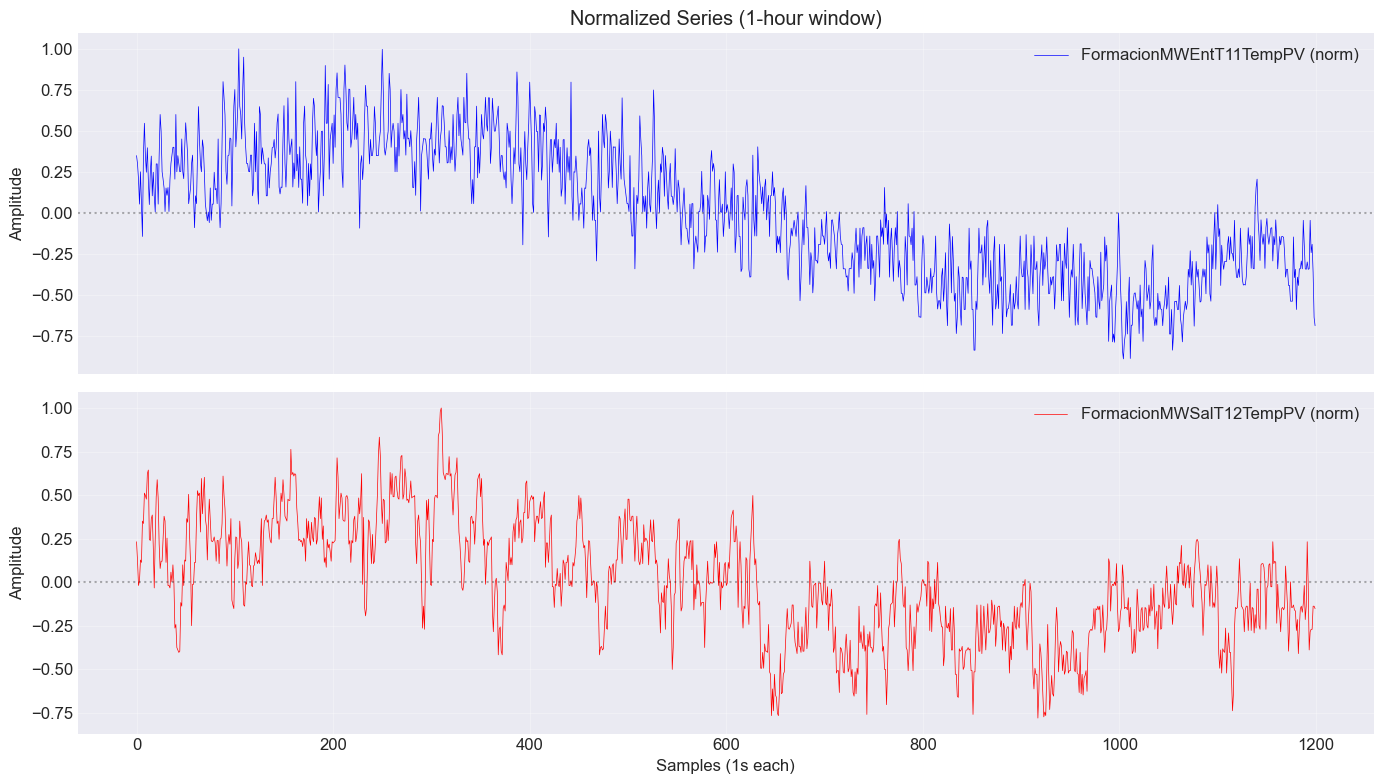

In [5]:
# Normalize to [-1, 1] centered at 0 (for Hilbert transform zero-crossings)
def normalize_zero_centered(x):
    """Normalize to [-1, 1] with zero mean."""
    x = np.asarray(x, dtype=float)
    x_centered = x - np.mean(x)
    max_abs = np.max(np.abs(x_centered))
    if max_abs > 0:
        return x_centered / max_abs
    return x_centered

s1_norm = normalize_zero_centered(s1)
s2_norm = normalize_zero_centered(s2)

print(f's1_norm: mean={np.mean(s1_norm):.6f}, std={np.std(s1_norm):.4f}, range=[{np.min(s1_norm):.4f}, {np.max(s1_norm):.4f}]')
print(f's2_norm: mean={np.mean(s2_norm):.6f}, std={np.std(s2_norm):.4f}, range=[{np.min(s2_norm):.4f}, {np.max(s2_norm):.4f}]')

# Plot normalized series
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
time_axis = np.arange(len(s1_norm))

axes[0].plot(time_axis, s1_norm, 'b-', linewidth=0.5, label='FormacionMWEntT11TempPV (norm)')
axes[0].axhline(y=0, color='k', linestyle=':', alpha=0.3)
axes[0].set_ylabel('Amplitude')
axes[0].set_title('Normalized Series (1-hour window)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(time_axis, s2_norm, 'r-', linewidth=0.5, label='FormacionMWSalT12TempPV (norm)')
axes[1].axhline(y=0, color='k', linestyle=':', alpha=0.3)
axes[1].set_ylabel('Amplitude')
axes[1].set_xlabel('Samples (1s each)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Mean Kuramoto r (lag=0): 0.8890
Std Kuramoto r (lag=0): 0.1745


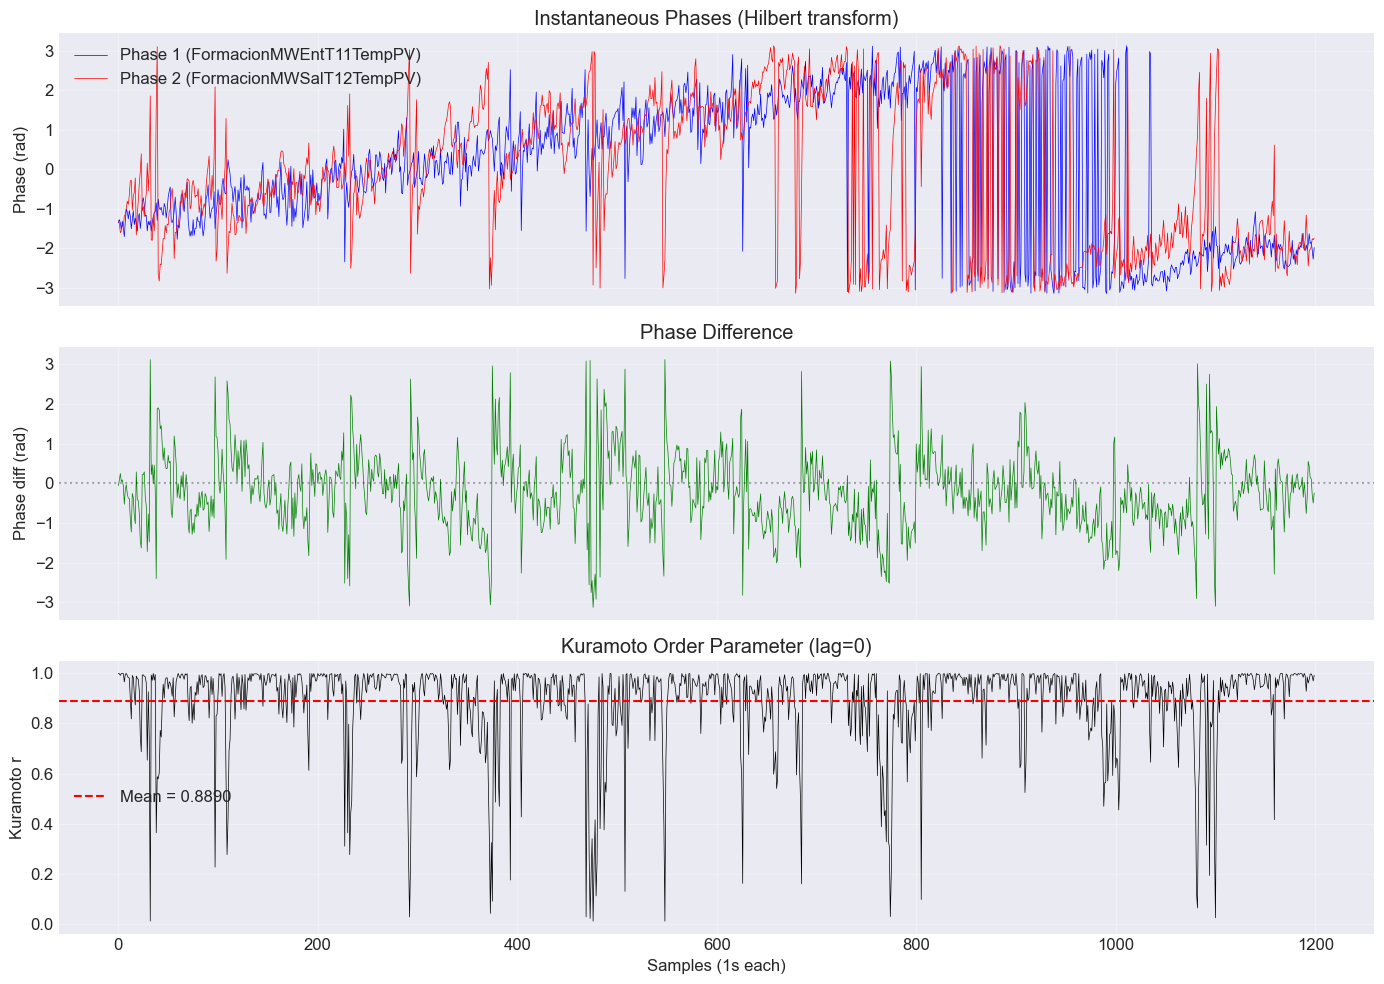

In [6]:
# Hilbert transform to extract phases
def get_phase(signal):
    """Get instantaneous phase using Hilbert transform."""
    analytic = hilbert(signal)
    phase = np.angle(analytic)  # Returns phase in [-pi, pi]
    return phase

# Kuramoto order parameter for 2 oscillators
def kuramoto_order_param(phi1, phi2):
    """Calculate Kuramoto order parameter r(t) for two phases.
    r = |(1/2) * (e^{i*phi1} + e^{i*phi2})|
    """
    z = 0.5 * (np.exp(1j * phi1) + np.exp(1j * phi2))
    r = np.abs(z)
    return r

# Test on original (lag=0)
phi1 = get_phase(s1_norm)
phi2 = get_phase(s2_norm)

r = kuramoto_order_param(phi1, phi2)

print(f'Mean Kuramoto r (lag=0): {np.mean(r):.4f}')
print(f'Std Kuramoto r (lag=0): {np.std(r):.4f}')

# Plot phases and order parameter
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

axes[0].plot(time_axis, phi1, 'b-', linewidth=0.5, label='Phase 1 (FormacionMWEntT11TempPV)')
axes[0].plot(time_axis, phi2, 'r-', linewidth=0.5, label='Phase 2 (FormacionMWSalT12TempPV)')
axes[0].set_ylabel('Phase (rad)')
axes[0].set_title('Instantaneous Phases (Hilbert transform)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Phase difference
phase_diff = np.angle(np.exp(1j * (phi1 - phi2)))
axes[1].plot(time_axis, phase_diff, 'g-', linewidth=0.5)
axes[1].axhline(y=0, color='k', linestyle=':', alpha=0.3)
axes[1].set_ylabel('Phase diff (rad)')
axes[1].set_title('Phase Difference')
axes[1].grid(True, alpha=0.3)

axes[2].plot(time_axis, r, 'k-', linewidth=0.5)
axes[2].axhline(y=np.mean(r), color='r', linestyle='--', label=f'Mean = {np.mean(r):.4f}')
axes[2].set_ylabel('Kuramoto r')
axes[2].set_xlabel('Samples (1s each)')
axes[2].set_title('Kuramoto Order Parameter (lag=0)')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [7]:
# Sweep lags and compute Kuramoto order parameter for each
max_lag = 600  # seconds (10 minutes)
lag_step = 10  # step size in seconds
lags = np.arange(-max_lag, max_lag + 1, lag_step)

results = []

for lag in lags:
    # Shift s2 relative to s1
    if lag > 0:
        # s2 delayed by lag -> shift s2 forward (pad beginning)
        s2_shifted = np.concatenate([np.full(lag, np.nan), s2_norm[:-lag]])
    elif lag < 0:
        # s2 advanced by |lag| -> shift s2 backward (pad end)
        s2_shifted = np.concatenate([s2_norm[-lag:], np.full(-lag, np.nan)])
    else:
        s2_shifted = s2_norm.copy()
    
    # Interpolate NaN from shift
    s2_shifted = pd.Series(s2_shifted).interpolate(limit_direction='both').values
    
    # Get phases
    phi1 = get_phase(s1_norm)
    phi2 = get_phase(s2_shifted)
    
    # Kuramoto order parameter
    r = kuramoto_order_param(phi1, phi2)
    
    # Metrics
    r_mean = np.mean(r)
    r_std = np.std(r)
    r_median = np.median(r)
    # Fraction of time r > threshold (sustained synchronization)
    threshold = 0.7
    frac_above = np.mean(r > threshold)
    # Longest continuous segment above threshold
    above = r > threshold
    max_sustained = 0
    current = 0
    for val in above:
        if val:
            current += 1
            max_sustained = max(max_sustained, current)
        else:
            current = 0
    
    results.append({
        'lag': lag,
        'r_mean': r_mean,
        'r_std': r_std,
        'r_median': r_median,
        'frac_above_07': frac_above,
        'max_sustained_sec': max_sustained
    })
    
    if len(results) % 20 == 0:
        print(f'Processed {len(results)}/{len(lags)} lags...')

results_df = pd.DataFrame(results)
print('Done!')

Processed 20/121 lags...
Processed 40/121 lags...
Processed 60/121 lags...
Processed 80/121 lags...
Processed 100/121 lags...
Processed 120/121 lags...
Done!


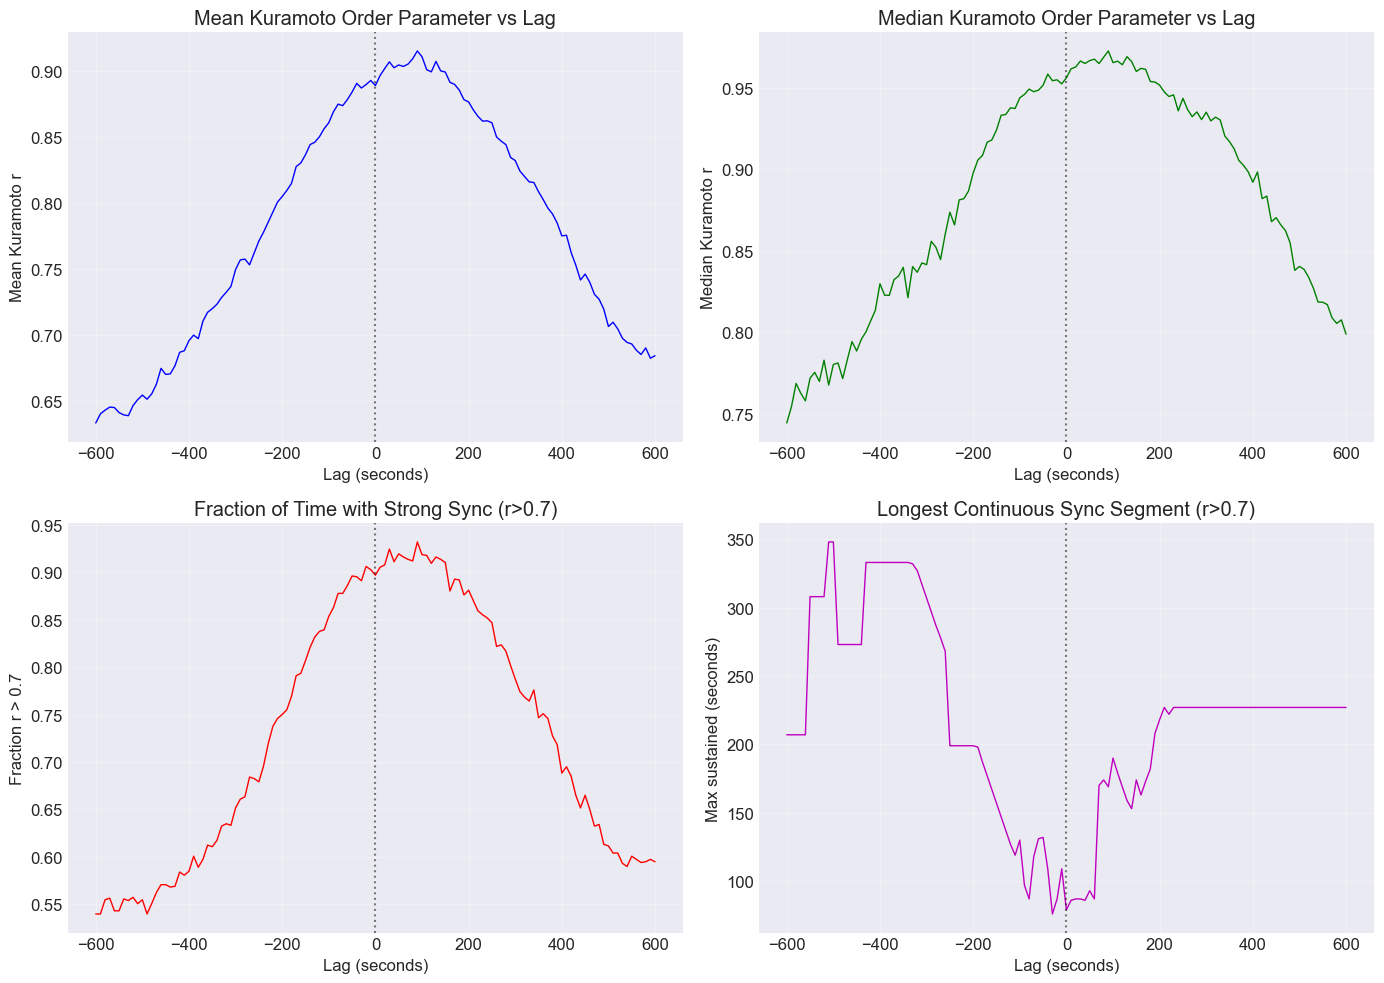

In [8]:
# Plot results
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0, 0].plot(results_df['lag'], results_df['r_mean'], 'b-', linewidth=1)
axes[0, 0].set_xlabel('Lag (seconds)')
axes[0, 0].set_ylabel('Mean Kuramoto r')
axes[0, 0].set_title('Mean Kuramoto Order Parameter vs Lag')
axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].axvline(x=0, color='k', linestyle=':', alpha=0.5)

axes[0, 1].plot(results_df['lag'], results_df['r_median'], 'g-', linewidth=1)
axes[0, 1].set_xlabel('Lag (seconds)')
axes[0, 1].set_ylabel('Median Kuramoto r')
axes[0, 1].set_title('Median Kuramoto Order Parameter vs Lag')
axes[0, 1].grid(True, alpha=0.3)
axes[0, 1].axvline(x=0, color='k', linestyle=':', alpha=0.5)

axes[1, 0].plot(results_df['lag'], results_df['frac_above_07'], 'r-', linewidth=1)
axes[1, 0].set_xlabel('Lag (seconds)')
axes[1, 0].set_ylabel('Fraction r > 0.7')
axes[1, 0].set_title('Fraction of Time with Strong Sync (r>0.7)')
axes[1, 0].grid(True, alpha=0.3)
axes[1, 0].axvline(x=0, color='k', linestyle=':', alpha=0.5)

axes[1, 1].plot(results_df['lag'], results_df['max_sustained_sec'], 'm-', linewidth=1)
axes[1, 1].set_xlabel('Lag (seconds)')
axes[1, 1].set_ylabel('Max sustained (seconds)')
axes[1, 1].set_title('Longest Continuous Sync Segment (r>0.7)')
axes[1, 1].grid(True, alpha=0.3)
axes[1, 1].axvline(x=0, color='k', linestyle=':', alpha=0.5)

plt.tight_layout()
plt.show()

In [9]:
# Find optimal lag
print('=== Top 10 lags by Mean Kuramoto r ===')
top_mean = results_df.nlargest(10, 'r_mean')[['lag', 'r_mean', 'r_std', 'frac_above_07', 'max_sustained_sec']]
print(top_mean.to_string(index=False))

print('\n=== Top 10 lags by Fraction r>0.7 ===')
top_frac = results_df.nlargest(10, 'frac_above_07')[['lag', 'r_mean', 'r_std', 'frac_above_07', 'max_sustained_sec']]
print(top_frac.to_string(index=False))

print('\n=== Top 10 lags by Max Sustained Sync ===')
top_sust = results_df.nlargest(10, 'max_sustained_sec')[['lag', 'r_mean', 'r_std', 'frac_above_07', 'max_sustained_sec']]
print(top_sust.to_string(index=False))

# Best lag considering multiple criteria
# Weight: mean_r * frac_above * (1 + max_sustained/3600) - penalize high std
results_df['score'] = results_df['r_mean'] * results_df['frac_above_07'] * (1 + results_df['max_sustained_sec'] / 3600) / (1 + results_df['r_std'])
best = results_df.nlargest(5, 'score')
print('\n=== Top 5 by Combined Score ===')
print(best[['lag', 'r_mean', 'r_std', 'frac_above_07', 'max_sustained_sec', 'score']].to_string(index=False))

=== Top 10 lags by Mean Kuramoto r ===
 lag   r_mean    r_std  frac_above_07  max_sustained_sec
  90 0.915215 0.150045       0.931667                169
 100 0.910812 0.149843       0.918333                190
  80 0.909317 0.153893       0.911667                174
 130 0.907278 0.151016       0.915833                159
  30 0.906948 0.151765       0.924167                 87
  70 0.905228 0.156354       0.913333                170
  50 0.904609 0.157933       0.919167                 93
  60 0.903480 0.157716       0.915833                 87
  40 0.902482 0.161541       0.910833                 86
  20 0.901892 0.150760       0.907500                 87

=== Top 10 lags by Fraction r>0.7 ===
 lag   r_mean    r_std  frac_above_07  max_sustained_sec
  90 0.915215 0.150045       0.931667                169
  30 0.906948 0.151765       0.924167                 87
  50 0.904609 0.157933       0.919167                 93
 100 0.910812 0.149843       0.918333                190
 110 0.901

Best lag: 90 seconds (1.5 minutes)
Mean r at best lag: 0.9152
Std r at best lag: 0.1500
Fraction r>0.7: 0.9317


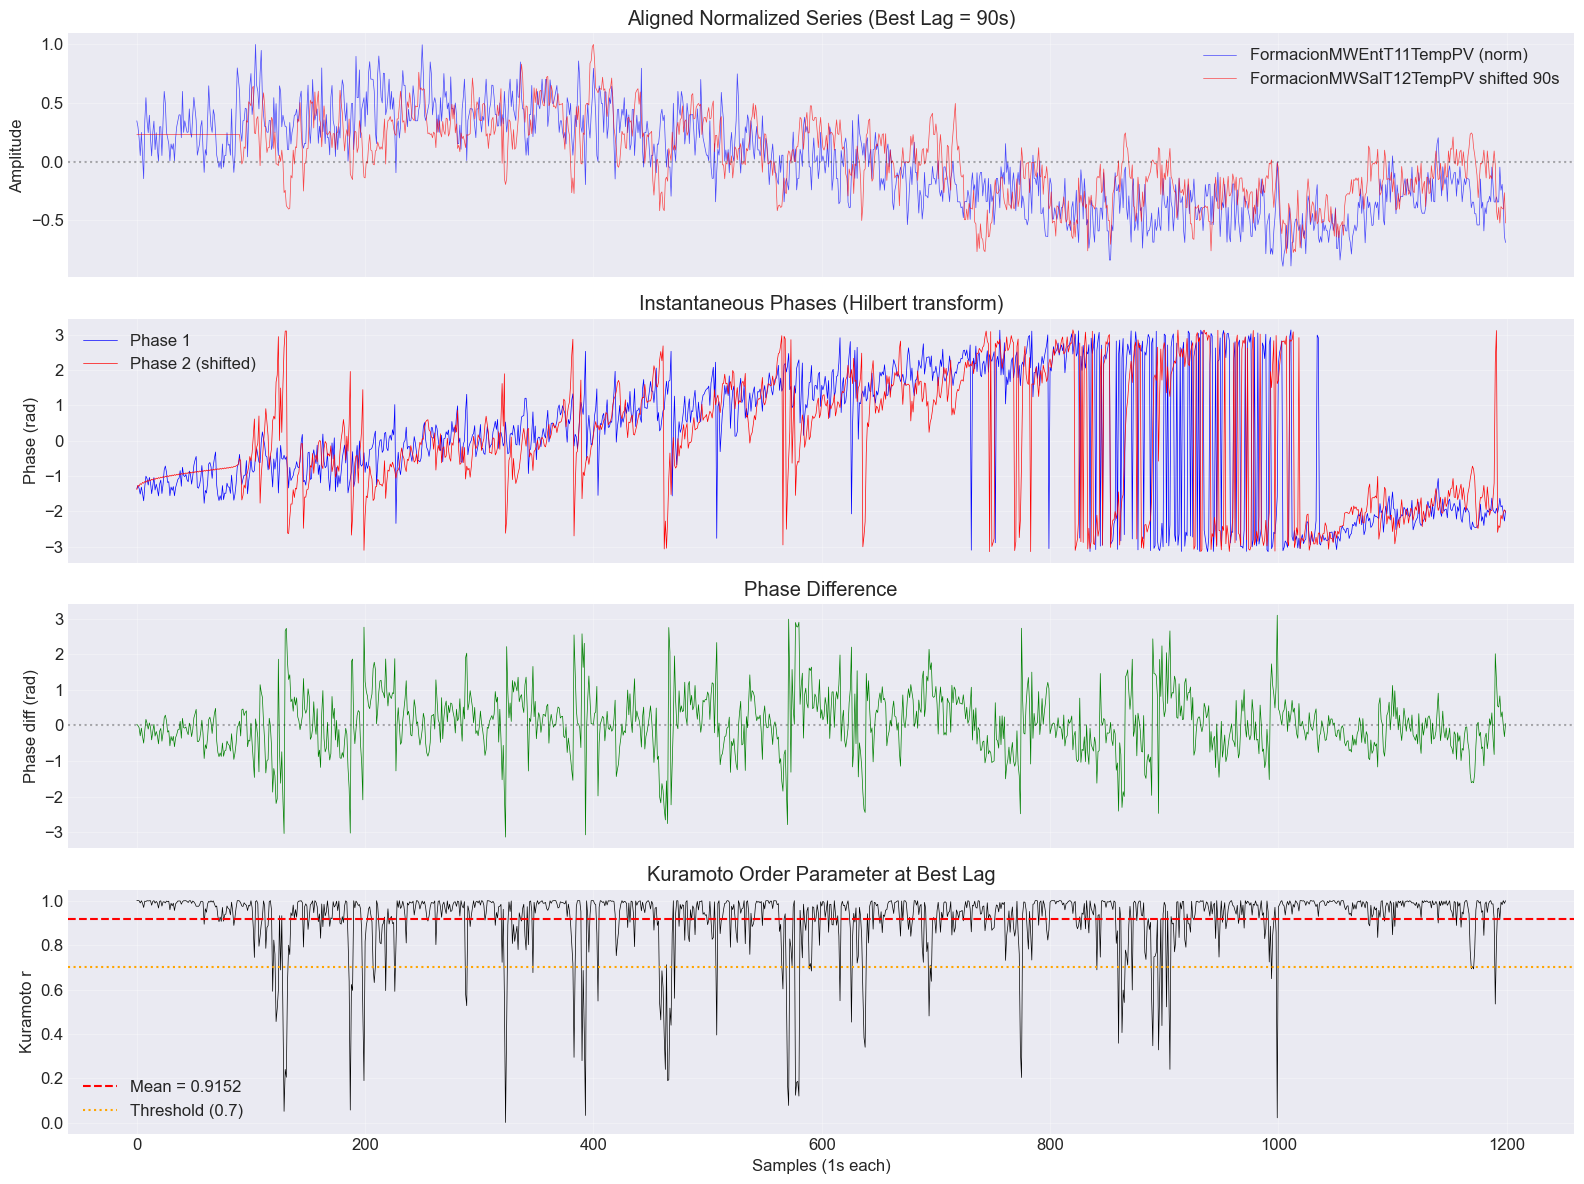

In [10]:
# Detailed analysis at best lag
best_lag = int(best.iloc[0]['lag'])
print(f'Best lag: {best_lag} seconds ({best_lag/60:.1f} minutes)')

# Apply best lag
if best_lag > 0:
    s2_best = np.concatenate([np.full(best_lag, np.nan), s2_norm[:-best_lag]])
elif best_lag < 0:
    s2_best = np.concatenate([s2_norm[-best_lag:], np.full(-best_lag, np.nan)])
else:
    s2_best = s2_norm.copy()
s2_best = pd.Series(s2_best).interpolate(limit_direction='both').values

phi1_best = get_phase(s1_norm)
phi2_best = get_phase(s2_best)
r_best = kuramoto_order_param(phi1_best, phi2_best)
phase_diff_best = np.angle(np.exp(1j * (phi1_best - phi2_best)))

print(f'Mean r at best lag: {np.mean(r_best):.4f}')
print(f'Std r at best lag: {np.std(r_best):.4f}')
print(f'Fraction r>0.7: {np.mean(r_best > 0.7):.4f}')

# Plot detailed sync at best lag
fig, axes = plt.subplots(4, 1, figsize=(16, 12), sharex=True)

axes[0].plot(time_axis, s1_norm, 'b-', linewidth=0.5, label='FormacionMWEntT11TempPV (norm)', alpha=0.7)
axes[0].plot(time_axis, s2_best, 'r-', linewidth=0.5, label=f'FormacionMWSalT12TempPV shifted {best_lag}s', alpha=0.7)
axes[0].axhline(y=0, color='k', linestyle=':', alpha=0.3)
axes[0].set_ylabel('Amplitude')
axes[0].set_title(f'Aligned Normalized Series (Best Lag = {best_lag}s)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(time_axis, phi1_best, 'b-', linewidth=0.5, label='Phase 1')
axes[1].plot(time_axis, phi2_best, 'r-', linewidth=0.5, label='Phase 2 (shifted)')
axes[1].set_ylabel('Phase (rad)')
axes[1].set_title('Instantaneous Phases (Hilbert transform)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

axes[2].plot(time_axis, phase_diff_best, 'g-', linewidth=0.5)
axes[2].axhline(y=0, color='k', linestyle=':', alpha=0.3)
axes[2].set_ylabel('Phase diff (rad)')
axes[2].set_title('Phase Difference')
axes[2].grid(True, alpha=0.3)

axes[3].plot(time_axis, r_best, 'k-', linewidth=0.5)
axes[3].axhline(y=np.mean(r_best), color='r', linestyle='--', label=f'Mean = {np.mean(r_best):.4f}')
axes[3].axhline(y=0.7, color='orange', linestyle=':', label='Threshold (0.7)')
axes[3].set_ylabel('Kuramoto r')
axes[3].set_xlabel('Samples (1s each)')
axes[3].set_title('Kuramoto Order Parameter at Best Lag')
axes[3].legend()
axes[3].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

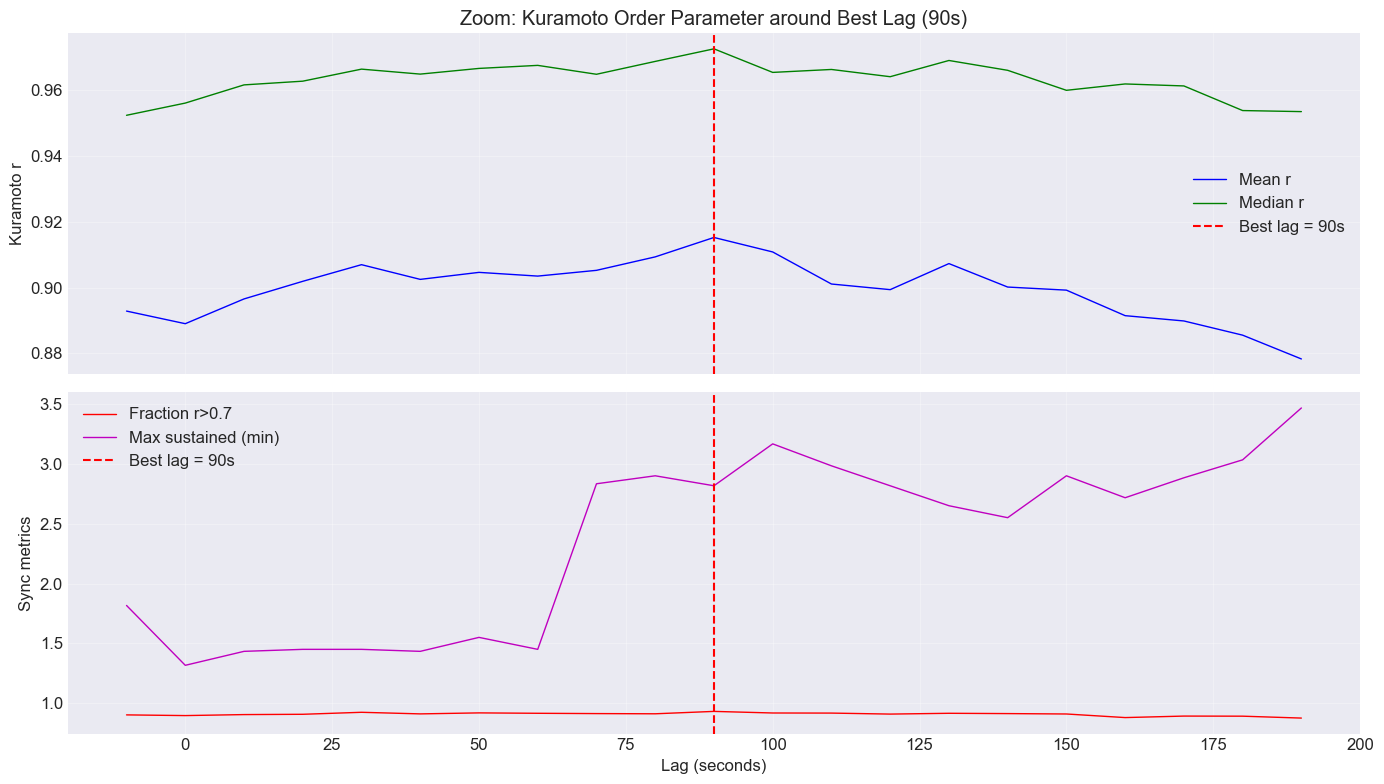

Maximum r: 0.9152
Lags within 1% of max: 30s to 130s (width: 100s)
Number of lag steps near max: 5


In [11]:
# Zoom in on the peak region around best lag
window = 100  # seconds around best lag
mask = (results_df['lag'] >= best_lag - window) & (results_df['lag'] <= best_lag + window)
peak_df = results_df[mask]

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

axes[0].plot(peak_df['lag'], peak_df['r_mean'], 'b-', linewidth=1, label='Mean r')
axes[0].plot(peak_df['lag'], peak_df['r_median'], 'g-', linewidth=1, label='Median r')
axes[0].axvline(x=best_lag, color='r', linestyle='--', label=f'Best lag = {best_lag}s')
axes[0].set_ylabel('Kuramoto r')
axes[0].set_title(f'Zoom: Kuramoto Order Parameter around Best Lag ({best_lag}s)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(peak_df['lag'], peak_df['frac_above_07'], 'r-', linewidth=1, label='Fraction r>0.7')
axes[1].plot(peak_df['lag'], peak_df['max_sustained_sec'] / 60, 'm-', linewidth=1, label='Max sustained (min)')
axes[1].axvline(x=best_lag, color='r', linestyle='--', label=f'Best lag = {best_lag}s')
axes[1].set_xlabel('Lag (seconds)')
axes[1].set_ylabel('Sync metrics')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Check if peak is sustained (flat top)
peak_r = peak_df['r_mean'].values
peak_lags = peak_df['lag'].values
max_r = np.max(peak_r)
# Lags where r is within 1% of max
near_max = peak_lags[peak_r >= 0.99 * max_r]
print(f'Maximum r: {max_r:.4f}')
print(f'Lags within 1% of max: {near_max[0]}s to {near_max[-1]}s (width: {near_max[-1] - near_max[0]}s)')
print(f'Number of lag steps near max: {len(near_max)}')

In [12]:
# Test with different 1-hour windows to verify robustness
windows = [
    ('2021-11-01 12:00:00', '2021-11-01 13:00:00'),
    ('2021-11-02 12:00:00', '2021-11-02 13:00:00'),
    ('2021-11-03 12:00:00', '2021-11-03 13:00:00'),
    ('2021-11-04 12:00:00', '2021-11-04 13:00:00'),
    ('2021-11-05 12:00:00', '2021-11-05 13:00:00'),
    ('2021-11-06 12:00:00', '2021-11-06 13:00:00'),
]

window_results = []

for start, end in windows:
    try:
        df_w = df.loc[start:end]
        if len(df_w) < 3000:  # Skip if too short
            continue
        s1_w = pd.Series(df_w['FormacionMWEntT11TempPV'].values).interpolate().values
        s2_w = pd.Series(df_w['FormacionMWSalT12TempPV'].values).interpolate().values
        
        s1_w_norm = normalize_zero_centered(s1_w)
        s2_w_norm = normalize_zero_centered(s2_w)
        
        # Quick scan with coarser step
        test_lags = np.arange(-600, 601, 30)
        best_r = -1
        best_l = 0
        for lag in test_lags:
            if lag > 0:
                s2_shifted = np.concatenate([np.full(lag, np.nan), s2_w_norm[:-lag]])
            elif lag < 0:
                s2_shifted = np.concatenate([s2_w_norm[-lag:], np.full(-lag, np.nan)])
            else:
                s2_shifted = s2_w_norm.copy()
            s2_shifted = pd.Series(s2_shifted).interpolate(limit_direction='both').values
            
            phi1 = get_phase(s1_w_norm)
            phi2 = get_phase(s2_shifted)
            r = kuramoto_order_param(phi1, phi2)
            
            if np.mean(r) > best_r:
                best_r = np.mean(r)
                best_l = lag
        
        window_results.append({
            'window': f'{start} to {end}',
            'best_lag': best_l,
            'best_r': best_r
        })
        print(f'{start} -> Best lag: {best_l}s, r={best_r:.4f}')
    except Exception as e:
        print(f'{start} -> Error: {e}')

print('\nSummary across windows:')
for wr in window_results:
    print(f"  {wr['window']}: lag={wr['best_lag']}s, r={wr['best_r']:.4f}")

2021-11-01 12:00:00 -> Best lag: 600s, r=0.8435
2021-11-03 12:00:00 -> Best lag: -360s, r=0.8600
2021-11-05 12:00:00 -> Best lag: -420s, r=0.7555
2021-11-06 12:00:00 -> Best lag: -90s, r=0.7793

Summary across windows:
  2021-11-01 12:00:00 to 2021-11-01 13:00:00: lag=600s, r=0.8435
  2021-11-03 12:00:00 to 2021-11-03 13:00:00: lag=-360s, r=0.8600
  2021-11-05 12:00:00 to 2021-11-05 13:00:00: lag=-420s, r=0.7555
  2021-11-06 12:00:00 to 2021-11-06 13:00:00: lag=-90s, r=0.7793


In [13]:
# Save results
results_df.to_parquet('../data/kuramoto_lag_sweep_T11_T12.parquet')
print('Saved lag sweep results to ../data/kuramoto_lag_sweep_T11_T12.parquet')

# Get max_sustained for best lag from results
max_sustained_sec = int(results_df.loc[results_df['lag'] == best_lag, 'max_sustained_sec'].values[0])

# Summary
print(f'\n=== FINAL RESULT ===')
print(f'Optimal lag (Kuramoto phase sync): {best_lag} seconds ({best_lag/60:.1f} minutes)')
print(f'Mean Kuramoto r at optimal lag: {np.mean(r_best):.4f}')
print(f'Fraction of time with strong sync (r>0.7): {np.mean(r_best > 0.7):.2%}')
print(f'Longest continuous sync segment: {max_sustained_sec}s ({max_sustained_sec/60:.1f} min)')

# Real lag (distance/speed)
lag = int(18600 / df['FormacionVelocidad'].loc[start_time:end_time].mean())
print(f'Real lag (|distance/speed|):                               {lag}s ({lag/60:.1f} min)')

Saved lag sweep results to ../data/kuramoto_lag_sweep_T11_T12.parquet

=== FINAL RESULT ===
Optimal lag (Kuramoto phase sync): 90 seconds (1.5 minutes)
Mean Kuramoto r at optimal lag: 0.9152
Fraction of time with strong sync (r>0.7): 93.17%
Longest continuous sync segment: 169s (2.8 min)
Real lag (|distance/speed|):                               90s (1.5 min)
